<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/DAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Run this cell ALONE first in every notebook
!pip install optuna -q
print("Optuna ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.3 MB/s eta 0:00:00
Optuna ready.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DAST — SNIPPET 1: PREPROCESSING + ARCHITECTURE
# Paper: Zhang et al. 2022, IEEE TIM
# "Dual Aspect Self-Attention based on Transformer for RUL Prediction"
#
# Architecture (paper Fig.1):
#   Input (B,T,k)
#   ├─ Sensor Enc   : transpose→(B,k,T)→embed→PE→N×EncoderBlock → Fs(B,k,D)
#   ├─ TimeStep Enc : (B,T,k)→embed→PE→N×EncoderBlock            → Ft(B,T,D)
#   ├─ Fusion       : Concat(Fs,Ft)→(B,k+T,D)→Linear             → Fr(B,k+T,D)
#   ├─ Decoder      : embed→PE→N×DecoderBlock(cross-attn Fr)      → (B,T,D)
#   └─ Output head  : Flatten→FC(64,ReLU)→FC(1)                   → RUL(B,1)
#
# NEW: forward+backward smoke test at the end of this snippet — runs build_dast
# on 4 dummy samples for 1 epoch. Catches any model-build error in <1s, before
# Snippet 5 ever launches the 40-trial search.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np, random, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Flatten, Layer
)
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

# ── Seeds ──────────────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

DATA_PATH = '/content/'
SEQ_LEN   = 40  # locked at 40; paper uses 60 for FD002/FD004

DATASET_CONFIG = {
    'FD001': {'rul_threshold': 125},
    'FD002': {'rul_threshold': 125},
    'FD003': {'rul_threshold': 125},
    'FD004': {'rul_threshold': 125},
}

# All 25 features (user requested; paper uses 14 after variance filtering)
ALL_FEATURES = ['cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22) if i not in [1, 5, 6, 10, 16, 18, 19]]
N_FEATURES   = len(ALL_FEATURES)  # 25

# ── Paper Table II default hyperparameters ─────────────────────────────────────
HP_DEFAULT = {
    # Architecture — from Table II
    'd_model'     : 64,    # Dmodel embedding/attention dimension
    'n_heads'     : 4,     # H self-attention heads (must divide d_model)
    'n_enc_layers': 2,     # N encoder blocks per stream (sensor + time-step)
    'n_dec_layers': 1,     # N decoder blocks
    'ff_dim'      : 128,   # FFN inner dim (paper unspecified; 2×d_model)
    'fc_units'    : 64,    # output FC hidden units (paper Table II: 64)
    'dropout'     : 0.2,   # paper: 0.2 for all encoder/decoder layers
    # Training
    'lr'          : 1e-3,  # paper: 0.001 with rectified Adam (RAdam)
    'batch_size'  : 64,    # paper: 256; reduced for Colab GPU
    'epochs'      : 100,   # paper: 100
    'patience_es' : 20,
    'patience_lr' : 7,
    'lr_factor'   : 0.5,
    'min_lr'      : 1e-7,
    'weight_decay': 0.0,   # L2 reg; paper unspecified
}

# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
def load_data(dataset):
    cols     = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
    train_df = pd.read_csv(f"{DATA_PATH}train_{dataset}.txt",
                           sep=r"\s+", header=None)
    train_df.columns = cols
    test_df  = pd.read_csv(f"{DATA_PATH}test_{dataset}.txt",
                           sep=r"\s+", header=None)
    test_df.columns  = cols
    y_test   = pd.read_csv(f"{DATA_PATH}RUL_{dataset}.txt",
                           header=None).values.flatten()
    return train_df, test_df, y_test

# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING
# Paper eq.12: X̃i = (Xi − min(Xi)) / (max(Xi) − min(Xi))  →  MinMax(0,1)
# ══════════════════════════════════════════════════════════════════════════════
def preprocess(train_df, test_df, dataset):
    cfg = DATASET_CONFIG[dataset]

    # Piecewise linear RUL label (clip at 125)
    max_c         = train_df.groupby('id')['cycle'].max().reset_index()
    max_c.columns = ['id','max_cycle']
    train_df      = train_df.merge(max_c, on='id')
    train_df['RUL'] = (train_df['max_cycle'] -
                       train_df['cycle']).clip(upper=cfg['rul_threshold'])
    train_df.drop(columns=['max_cycle'], inplace=True)

    # MinMax(0,1) — scaler fitted on TRAIN only, applied to test
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_df[ALL_FEATURES] = scaler.fit_transform(train_df[ALL_FEATURES])
    test_df[ALL_FEATURES]  = scaler.transform(test_df[ALL_FEATURES])
    return train_df, test_df

# ══════════════════════════════════════════════════════════════════════════════
# SEQUENCE GENERATION — stride=1 as in paper
# ══════════════════════════════════════════════════════════════════════════════
def create_sequences(df, seq_len):
    """Sliding window sequences for training/validation."""
    Xs, ys = [], []
    for eid in df['id'].unique():
        d = df[df['id'] == eid][ALL_FEATURES + ['RUL']].values
        for i in range(len(d) - seq_len):
            Xs.append(d[i:i+seq_len, :-1])   # (seq_len, n_features)
            ys.append(d[i+seq_len, -1])        # scalar RUL label
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32))

def create_test_sequences(test_df, seq_len):
    """Last window per engine; zero-pad if shorter than seq_len."""
    Xs = []
    for eid in test_df['id'].unique():
        d = test_df[test_df['id'] == eid][ALL_FEATURES].values
        if len(d) < seq_len:
            pad = np.zeros((seq_len - len(d), N_FEATURES), dtype=np.float32)
            d   = np.vstack([pad, d])
        else:
            d = d[-seq_len:]
        Xs.append(d)
    return np.array(Xs, dtype=np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# OPTIONAL: STATISTICAL FEATURES (paper section IV-B-1)
# "mean value and regression coefficient estimates"
# Appends per-sensor mean and slope to each timestep → shape (T, 3k)
# Uncomment use in create_sequences if desired
# ══════════════════════════════════════════════════════════════════════════════
def add_statistical_features(X):
    """X: (N, T, k) → output: (N, T, 3k)"""
    N, T, k   = X.shape
    t         = np.linspace(0, 1, T, dtype=np.float32)
    t_mean    = t.mean()
    t_denom   = ((t - t_mean)**2).sum() + 1e-8
    means     = X.mean(axis=1, keepdims=True)                            # (N,1,k)
    slopes    = (((t[:,None] - t_mean) * (X - means)).sum(axis=1,
                  keepdims=True) / t_denom)                              # (N,1,k)
    means_rep  = np.broadcast_to(means,  (N, T, k)).copy()
    slopes_rep = np.broadcast_to(slopes, (N, T, k)).copy()
    return np.concatenate([X, means_rep, slopes_rep], axis=-1).astype(np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# METRICS
# ══════════════════════════════════════════════════════════════════════════════
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

def report_metrics(name, true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"  {name:40s} RMSE={rmse:.3f}  MAE={mae:.3f}  NASA={nasa:.1f}")
    return rmse, mae, mse, nasa

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════
def plot_loss(h, ds):
    plt.figure(figsize=(10,4))
    plt.plot(h.history['loss'],     label='Train')
    plt.plot(h.history['val_loss'], label='Val')
    plt.title(f'DAST Loss — {ds}'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(); plt.show()

def plot_predictions(y_test, pred, ds):
    plt.figure(figsize=(14,4))
    plt.plot(y_test, label='Actual',    color='black',     lw=2)
    plt.plot(pred,   label='DAST Pred', color='royalblue', lw=1.5, alpha=0.85)
    plt.title(f'Actual vs Predicted RUL — DAST ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('RUL')
    plt.legend(); plt.grid(); plt.show()

def plot_residuals(y_test, pred, ds):
    res = y_test - pred
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(res)), res, alpha=0.5, s=15, color='royalblue')
    plt.axhline(0, color='black', ls='--', lw=1.5)
    plt.title(f'Residuals — DAST ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('Actual − Predicted')
    plt.grid(); plt.show()

def plot_rmse_bar(results_dict, title='DAST — Test RMSE'):
    ds_list = list(results_dict.keys())
    vals    = [results_dict[ds]['rmse'] for ds in ds_list]
    plt.figure(figsize=(8,5))
    bars = plt.bar(ds_list, vals, color='royalblue', edgecolor='white', alpha=0.85)
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.title(title); plt.ylabel('Test RMSE')
    plt.grid(axis='y'); plt.show()

def plot_rul_dist(train_df, ds):
    plt.figure(figsize=(10,4))
    plt.hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='white')
    plt.title(f'RUL Distribution — {ds}')
    plt.xlabel('RUL'); plt.ylabel('Frequency'); plt.grid(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# MODEL COMPONENTS
# ══════════════════════════════════════════════════════════════════════════════

class SinusoidalPE(Layer):
    """
    Sinusoidal Positional Encoding — paper equations 2-3:
      Pt(2k)   = sin(t / 10000^(2k / Dmodel))
      Pt(2k+1) = cos(t / 10000^(2k / Dmodel))
    Pre-computed and stored as non-trainable constant tensor.
    """
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(trainable=False, **kwargs)
        pos  = np.arange(seq_len)[:, None].astype(np.float32)    # (L, 1)
        dims = np.arange(d_model)[None, :].astype(np.float32)    # (1, D)
        ang  = pos / np.power(10000.0, (2*(dims//2)) / float(d_model))
        pe   = np.zeros_like(ang, dtype=np.float32)
        pe[:, 0::2] = np.sin(ang[:, 0::2])
        pe[:, 1::2] = np.cos(ang[:, 1::2])
        # (1, L, D) — broadcasts over batch dimension
        self._pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        return x + self._pe   # (batch, L, D) + (1, L, D)


class EncoderBlock(Layer):
    """
    One Transformer encoder layer — used for BOTH sensor and time-step encoders.
    Structure (paper Fig. 1 encoder sub-block):
      Multi-head Self-Attention → Add & Norm → FFN → Add & Norm
    Identical architecture; differs only in what dimension serves as the sequence.
    """
    def __init__(self, d_model, n_heads, ff_dim, dropout, **kwargs):
        super().__init__(**kwargs)
        self.mha   = MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.ff1   = Dense(ff_dim, activation='relu')
        self.ff2   = Dense(d_model)
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)

    def call(self, x, training=False):
        # Self-attention
        attn = self.mha(x, x, training=training)
        x    = self.norm1(x + self.drop1(attn, training=training))
        # Position-wise FFN
        ffn  = self.ff2(self.ff1(x))
        x    = self.norm2(x + self.drop2(ffn, training=training))
        return x  # shape unchanged


class DecoderBlock(Layer):
    """
    One Transformer decoder layer — paper Fig. 1 decoder sub-block:
      1. Masked Self-Attention (causal)        → Add & Norm
      2. Encoder-Decoder Cross-Attention       → Add & Norm
         Q: decoder states, K/V: fused encoder Fr
      3. FFN                                   → Add & Norm
    """
    def __init__(self, d_model, n_heads, ff_dim, dropout, **kwargs):
        super().__init__(**kwargs)
        self.mha_self  = MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.mha_cross = MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.ff1   = Dense(ff_dim, activation='relu')
        self.ff2   = Dense(d_model)
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.norm3 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)
        self.drop3 = Dropout(dropout)

    def call(self, x, enc_output, training=False):
        T = tf.shape(x)[1]

        # Causal mask: lower-triangular bool (T, T)
        # causal[i,j] = True → query i can attend to key j (j ≤ i)
        causal = tf.linalg.band_part(
            tf.ones((T, T), dtype=tf.bool), -1, 0)

        # 1. Masked self-attention (prevents attending to future positions)
        a1 = self.mha_self(x, x, attention_mask=causal, training=training)
        x  = self.norm1(x + self.drop1(a1, training=training))

        # 2. Cross-attention: Q from decoder, K/V from fused encoder output Fr
        #    x    : (B, T,   D)   ← queries
        #    enc  : (B, k+T, D)   ← keys and values
        a2 = self.mha_cross(x, enc_output, training=training)
        x  = self.norm2(x + self.drop2(a2, training=training))

        # 3. FFN
        ffn = self.ff2(self.ff1(x))
        x   = self.norm3(x + self.drop3(ffn, training=training))
        return x  # (B, T, D)


# ══════════════════════════════════════════════════════════════════════════════
# DAST MODEL
# ══════════════════════════════════════════════════════════════════════════════
class DASTModel(tf.keras.Model):
    """
    Dual Aspect Self-Attention based on Transformer (DAST)
    Zhang, Song, Li — IEEE TIM 2022  [arXiv:2106.15842]

    Full forward pass dimensions (T=40, k=25, D=64):
      Input       : (B, 40, 25)
      Sensor enc  : transpose→(B,25,40)→embed(40→64)→PE→2×Enc → Fs (B,25,64)
      TimeStep enc: (B,40,25)→embed(25→64)→PE→2×Enc             → Ft (B,40,64)
      Fusion      : Concat→(B,65,64)→Dense(64)                   → Fr (B,65,64)
      Decoder     : embed(25→64)→PE→1×Dec(cross-attn Fr)         → (B,40,64)
      Flatten     : (B,2560)
      FC(64,ReLU) : (B,64)
      Output      : (B,1)
    """
    def __init__(self, seq_len, n_features, hp):
        super().__init__()
        D  = hp['d_model']
        nh = hp['n_heads']
        ne = hp['n_enc_layers']
        nd = hp['n_dec_layers']
        ff = hp['ff_dim']
        dr = hp['dropout']
        fc = hp['fc_units']

        # ── Sensor encoder stream ──────────────────────────────────────────
        # After transpose: (B, k, T) — each "token" is a sensor row of length T
        self.s_embed = Dense(D, name='s_embed')      # T → D
        self.s_pe    = SinusoidalPE(n_features, D, name='s_pe')  # PE over k
        self.s_drop  = Dropout(dr)
        self.s_enc   = [EncoderBlock(D, nh, ff, dr, name=f's_enc_{i}')
                        for i in range(ne)]

        # ── Time-step encoder stream ───────────────────────────────────────
        # Input: (B, T, k) — each "token" is a time-step with k features
        self.ts_embed = Dense(D, name='ts_embed')    # k → D
        self.ts_pe    = SinusoidalPE(seq_len, D, name='ts_pe')   # PE over T
        self.ts_drop  = Dropout(dr)
        self.ts_enc   = [EncoderBlock(D, nh, ff, dr, name=f'ts_enc_{i}')
                         for i in range(ne)]

        # ── Feature fusion layer (eq.11) ───────────────────────────────────
        # Fr = Concat(Fs, Ft) @ Wf — projection keeps shape (B, k+T, D)
        self.fusion = Dense(D, name='fusion')

        # ── Decoder ────────────────────────────────────────────────────────
        self.dec_embed = Dense(D, name='dec_embed')   # k → D
        self.dec_pe    = SinusoidalPE(seq_len, D, name='dec_pe')
        self.dec_drop  = Dropout(dr)
        self.dec_layers = [DecoderBlock(D, nh, ff, dr, name=f'dec_{i}')
                           for i in range(nd)]

        # ── Output head ────────────────────────────────────────────────────
        self.flat    = Flatten()
        self.fc      = Dense(fc, activation='relu', name='fc')
        self.fc_drop = Dropout(dr)
        self.out     = Dense(1, name='rul_output')

    def call(self, inputs, training=False):
        # inputs: (B, T, k)

        # ── Sensor Encoder ─────────────────────────────────────────────────
        s = tf.transpose(inputs, perm=[0, 2, 1])   # (B, k, T)
        s = self.s_embed(s)                          # (B, k, D)
        s = self.s_pe(s)                             # + sinusoidal PE (k positions)
        s = self.s_drop(s, training=training)
        for enc in self.s_enc:
            s = enc(s, training=training)
        Fs = s  # (B, k, D)

        # ── Time-Step Encoder ──────────────────────────────────────────────
        t = self.ts_embed(inputs)                    # (B, T, D)
        t = self.ts_pe(t)                            # + sinusoidal PE (T positions)
        t = self.ts_drop(t, training=training)
        for enc in self.ts_enc:
            t = enc(t, training=training)
        Ft = t  # (B, T, D)

        # ── Feature Fusion (paper eq.11) ───────────────────────────────────
        # Fs: (B, k, D)   Ft: (B, T, D)
        # Concat along sequence dimension → (B, k+T, D)
        Fr = tf.concat([Fs, Ft], axis=1)             # (B, k+T, D)
        Fr = self.fusion(Fr)                          # (B, k+T, D)  [Wf projection]

        # ── Decoder ────────────────────────────────────────────────────────
        dec = self.dec_embed(inputs)                  # (B, T, D)
        dec = self.dec_pe(dec)                        # + PE
        dec = self.dec_drop(dec, training=training)
        for layer in self.dec_layers:
            # Cross-attention: Q=dec, K/V=Fr (fused sensor+timestep features)
            dec = layer(dec, Fr, training=training)
        # dec: (B, T, D)

        # ── Output ─────────────────────────────────────────────────────────
        x   = self.flat(dec)                          # (B, T*D = 2560)
        x   = self.fc(x)                              # (B, fc_units = 64)
        x   = self.fc_drop(x, training=training)
        out = self.out(x)                             # (B, 1)
        return out


def build_dast(seq_len, n_features, hp):
    """Build, trigger compile, return DAST model."""
    model = DASTModel(seq_len, n_features, hp)
    # Trigger weight creation via dummy forward pass
    _ = model(tf.zeros((2, seq_len, n_features)), training=False)
    model.compile(
        optimizer=Adam(learning_rate=hp['lr'], clipnorm=1.0),
        loss='mse',    # MSE ≡ RMSE for gradient descent; paper trains with RMSE
        metrics=['mae']
    )
    return model

# ══════════════════════════════════════════════════════════════════════════════
# VERIFICATION
# ══════════════════════════════════════════════════════════════════════════════
print("="*60)
print("  DAST ARCHITECTURE")
print("="*60)
_m = build_dast(SEQ_LEN, N_FEATURES, HP_DEFAULT)
_m.summary()

D = HP_DEFAULT['d_model']
print(f"\n  Shape flow (T={SEQ_LEN}, k={N_FEATURES}, D={D}):")
print(f"    Input       : (B, {SEQ_LEN}, {N_FEATURES})")
print(f"    Fs          : (B, {N_FEATURES}, {D})")
print(f"    Ft          : (B, {SEQ_LEN}, {D})")
print(f"    Fr (fused)  : (B, {N_FEATURES+SEQ_LEN}, {D})")
print(f"    Decoder out : (B, {SEQ_LEN}, {D})")
print(f"    Flatten     : (B, {SEQ_LEN*D})")
print(f"    FC({HP_DEFAULT['fc_units']})     : (B, {HP_DEFAULT['fc_units']})")
print(f"    Output      : (B, 1)")

# NEW: forward + backward smoke test — catches build/op errors in <1s
print("\n  Running forward+backward smoke test (1 epoch, 4 dummy samples)...")
_X_d = np.random.randn(4, SEQ_LEN, N_FEATURES).astype(np.float32)
_y_d = (np.random.rand(4) * 125).astype(np.float32)
_m.fit(_X_d, _y_d, epochs=1, batch_size=4, verbose=0)
print("  Smoke test passed — model builds and trains cleanly.")
del _m, _X_d, _y_d

print(f"\n  Dataset check:")
for ds in ['FD001','FD002','FD003','FD004']:
    tr, te, y = load_data(ds)
    print(f"    {ds}: train={tr.shape}  test={te.shape}  y_test={y.shape}")
print("\n  Snippet 1 ready.\n")

  DAST ARCHITECTURE


Model: "dast_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ s_embed (Dense)                 │ (2, 18, 64)            │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_pe (SinusoidalPE)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_enc_0 (EncoderBlock)          │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_enc_1 (EncoderBlock)          │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ts_embed (Dense)                │ (2, 40, 64)            │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ts_pe (SinusoidalPE)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ts_enc_0 (EncoderBlock)         │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ts_enc_1 (EncoderBlock)         │ ?                      │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion (Dense)                  │ (2, 58, 64)            │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_embed (Dense)               │ (2, 40, 64)            │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_pe (SinusoidalPE)           │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_0 (DecoderBlock)            │ ?                      │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (2, 2560)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (2, 64)                │       163,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (2, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,313 (1.36 MB)

 Trainable params: 357,313 (1.36 MB)

 Non-trainable params: 0 (0.00 B)


  Shape flow (T=40, k=18, D=64):
    Input       : (B, 40, 18)
    Fs          : (B, 18, 64)
    Ft          : (B, 40, 64)
    Fr (fused)  : (B, 58, 64)
    Decoder out : (B, 40, 64)
    Flatten     : (B, 2560)
    FC(64)     : (B, 64)
    Output      : (B, 1)

  Running forward+backward smoke test (1 epoch, 4 dummy samples)...
  Smoke test passed — model builds and trains cleanly.

  Dataset check:
    FD001: train=(20631, 26)  test=(13096, 26)  y_test=(100,)
    FD002: train=(53759, 26)  test=(33991, 26)  y_test=(259,)
    FD003: train=(24720, 26)  test=(16596, 26)  y_test=(100,)
    FD004: train=(61249, 26)  test=(41214, 26)  y_test=(248,)

  Snippet 1 ready.




████████████████████████████████████████████████████████████
  DAST BASELINE  —  Paper Default Hyperparameters
  d_model=64  H=4  N_enc=2  N_dec=1
  lr=0.001  batch=64  dropout=0.2
████████████████████████████████████████████████████████████

───────────────────────────────────────────────────────
  DATASET: FD001
───────────────────────────────────────────────────────


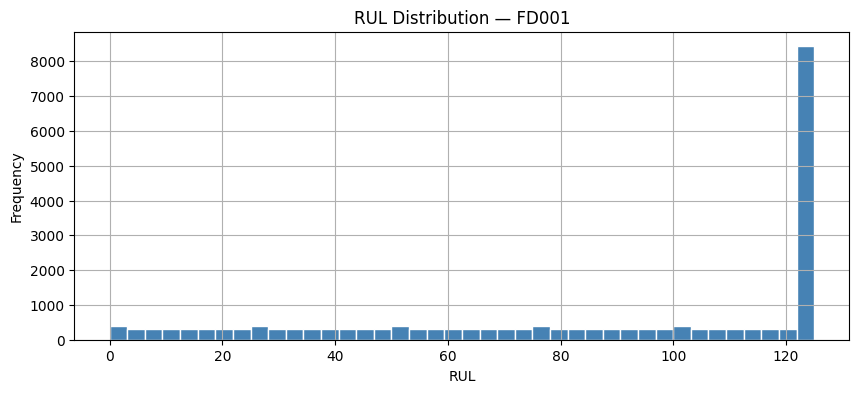

  Train:(13361, 40, 18)  Val:(3270, 40, 18)  Test:(100, 40, 18)
  HP: d=64 H=4 Ne=2 Nd=1 ff=128 lr=1e-03 bs=64

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

  Val  ↓
  DAST                                     RMSE=11.800  MAE=8.419  NASA=8232.9
  Test ↓
  DAST                                     RMSE=14.998  MAE=11.997  NASA=396.1


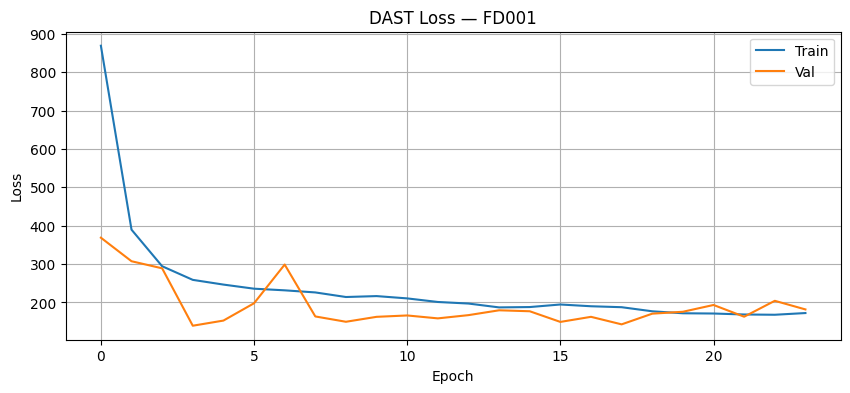

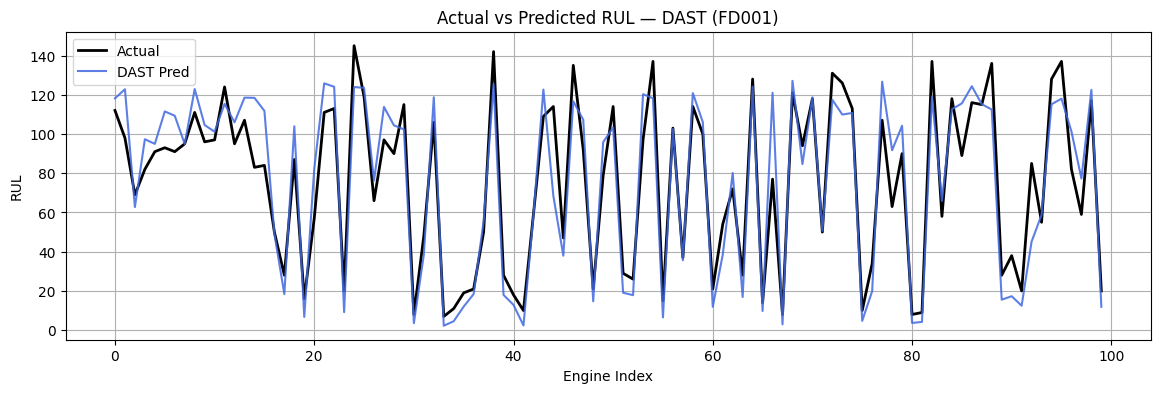

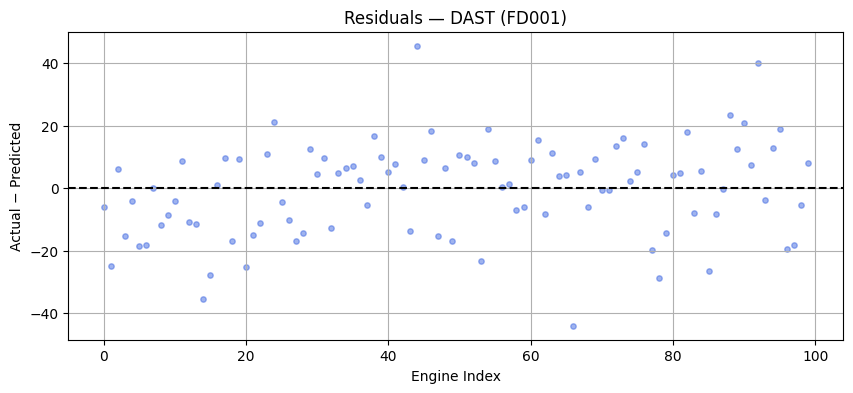


───────────────────────────────────────────────────────
  DATASET: FD002
───────────────────────────────────────────────────────


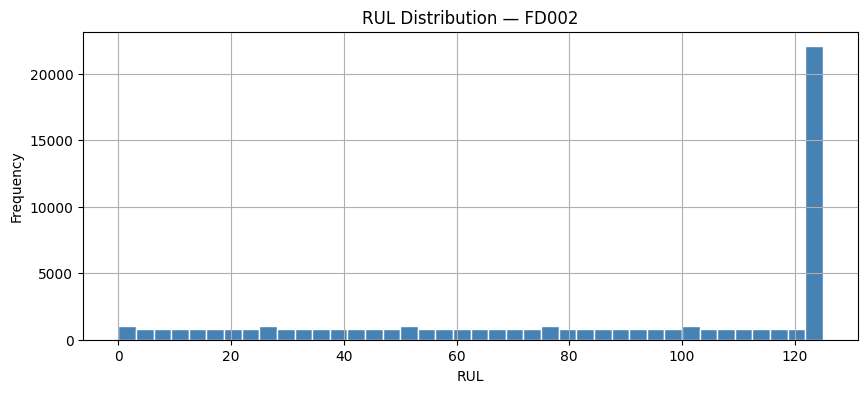

  Train:(35144, 40, 18)  Val:(8215, 40, 18)  Test:(259, 40, 18)
  HP: d=64 H=4 Ne=2 Nd=1 ff=128 lr=1e-03 bs=64

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

  Val  ↓
  DAST                                     RMSE=17.756  MAE=12.634  NASA=82598.4
  Test ↓
  DAST                                     RMSE=26.732  MAE=18.744  NASA=10417.9


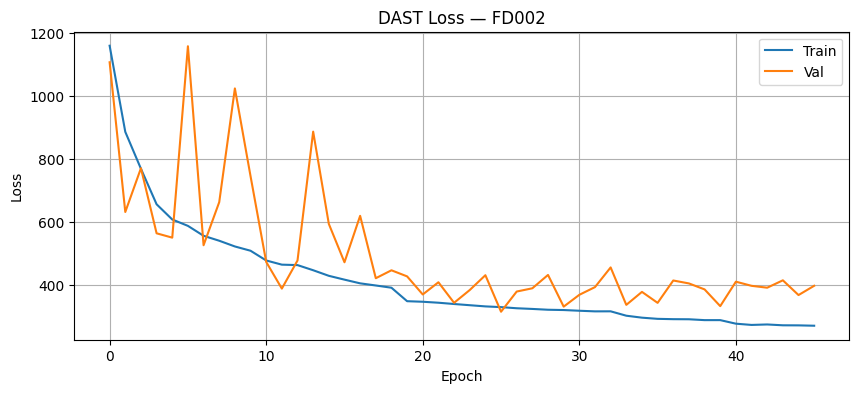

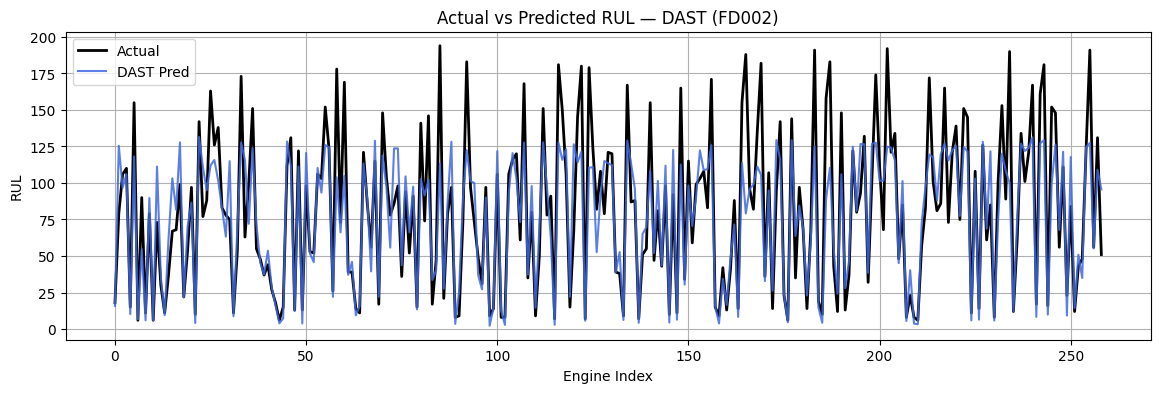

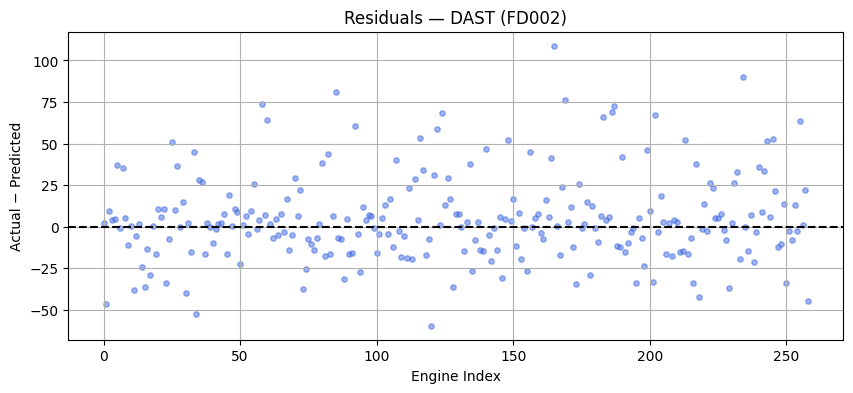


───────────────────────────────────────────────────────
  DATASET: FD003
───────────────────────────────────────────────────────


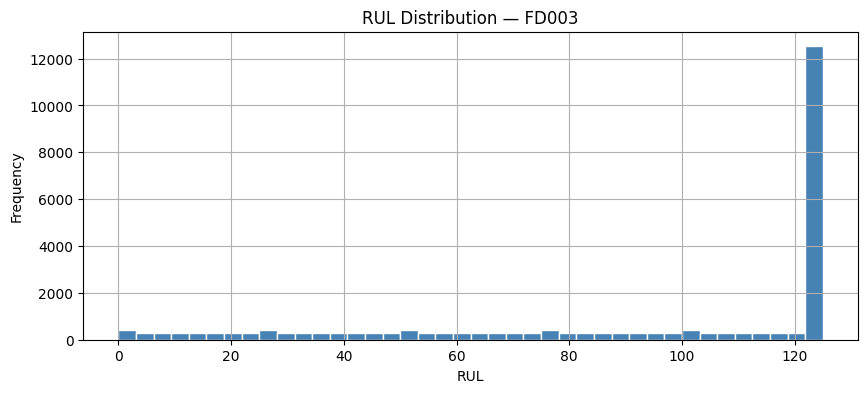

  Train:(16812, 40, 18)  Val:(3908, 40, 18)  Test:(100, 40, 18)
  HP: d=64 H=4 Ne=2 Nd=1 ff=128 lr=1e-03 bs=64

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 49: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 56: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

  Val  ↓
  DAST                                     RMSE=9.862  MAE=7.043  NASA=6315.5
  Test ↓
  DAST                                     RMSE=16.895  MAE=11.340  NASA=777.2


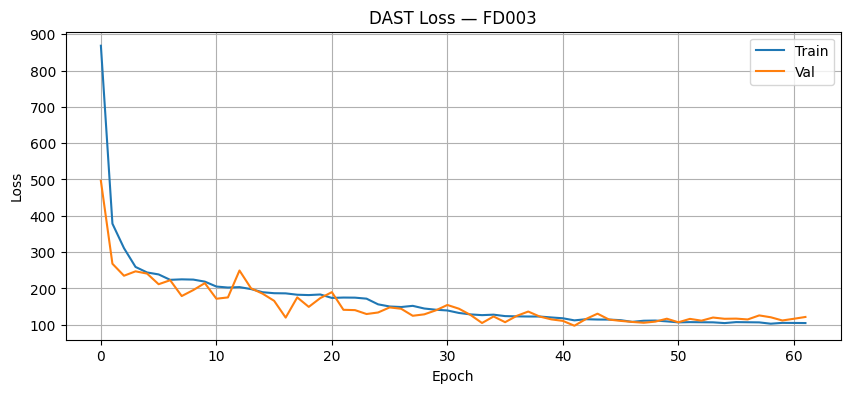

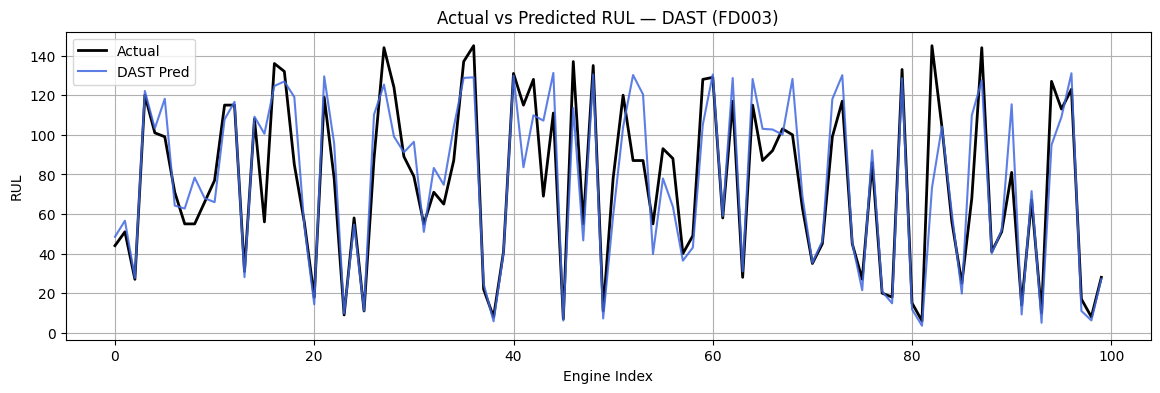

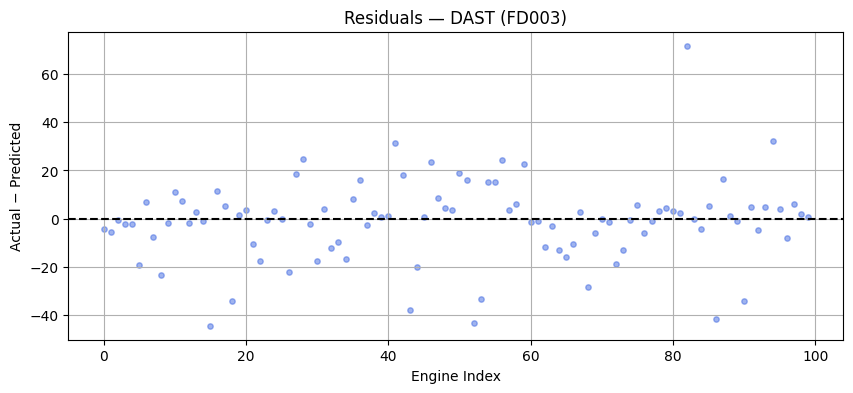


───────────────────────────────────────────────────────
  DATASET: FD004
───────────────────────────────────────────────────────


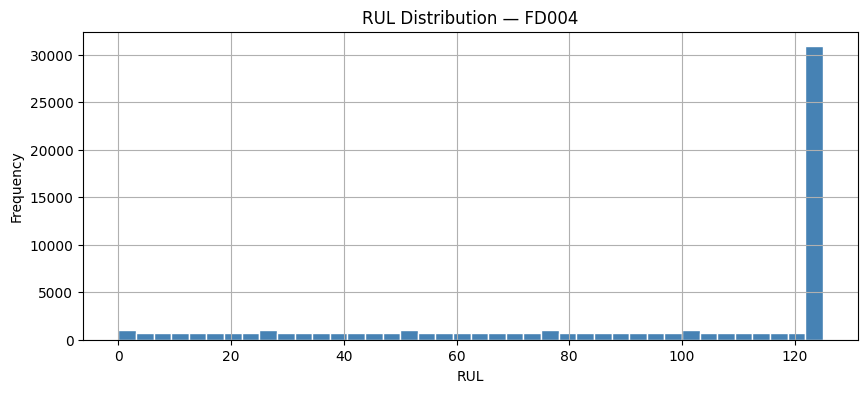

  Train:(41334, 40, 18)  Val:(9955, 40, 18)  Test:(248, 40, 18)
  HP: d=64 H=4 Ne=2 Nd=1 ff=128 lr=1e-03 bs=64

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 58: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 65: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

  Val  ↓
  DAST                                     RMSE=20.623  MAE=13.878  NASA=189750.2
  Test ↓
  DAST                                     RMSE=28.431  MAE=21.179  NASA=6444.0


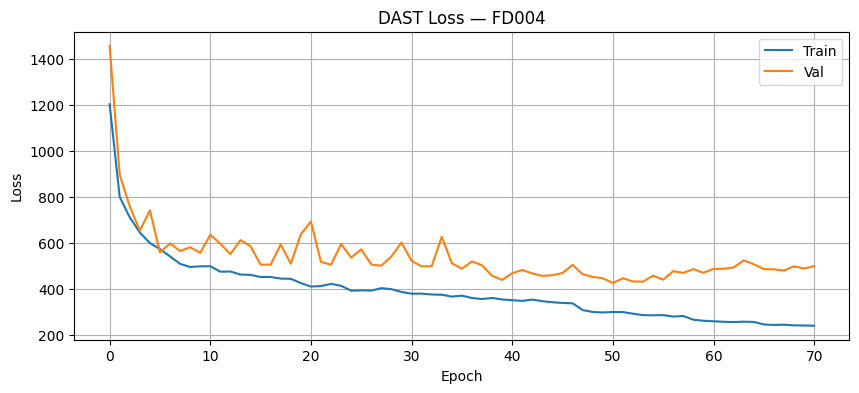

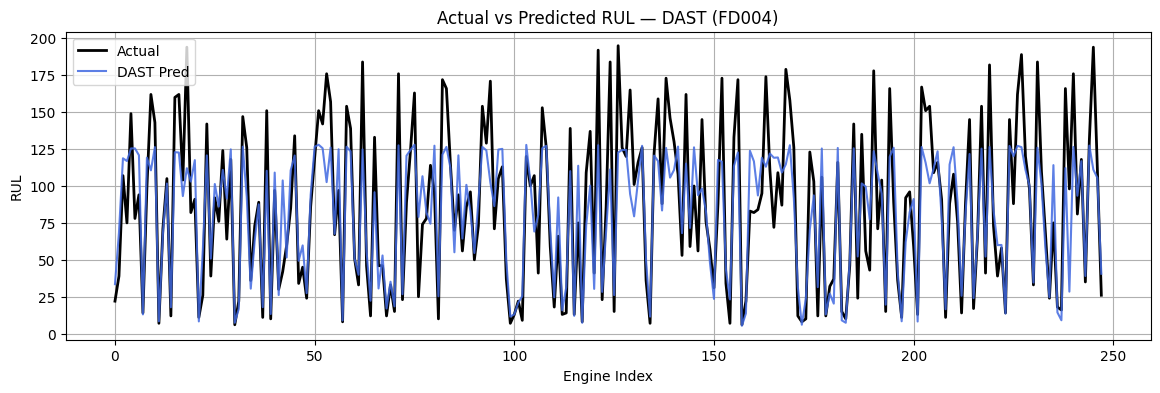

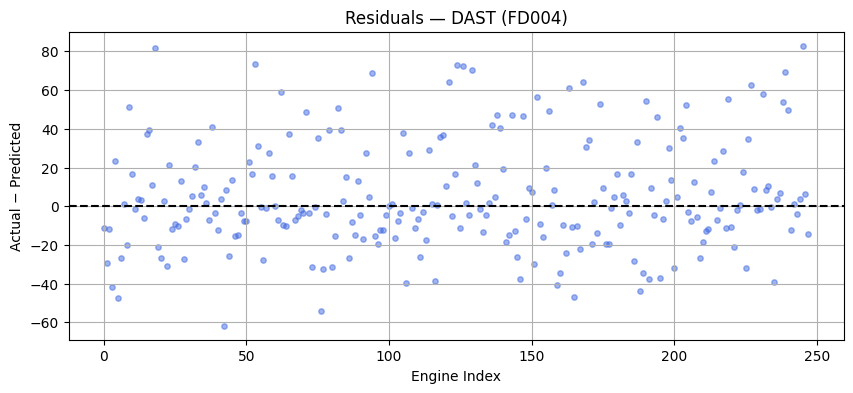


═════════════════════════════════════════════════════════════════
  DAST BASELINE RESULTS
═════════════════════════════════════════════════════════════════
  Dataset        RMSE      MAE        MSE       NASA
  ────────── ──────── ──────── ────────── ──────────
  FD001        14.998   11.997    224.944      396.1
  FD002        26.732   18.744    714.618    10417.9
  FD003        16.895   11.340    285.437      777.2
  FD004        28.431   21.179    808.309     6444.0

  Avg RMSE: 21.764


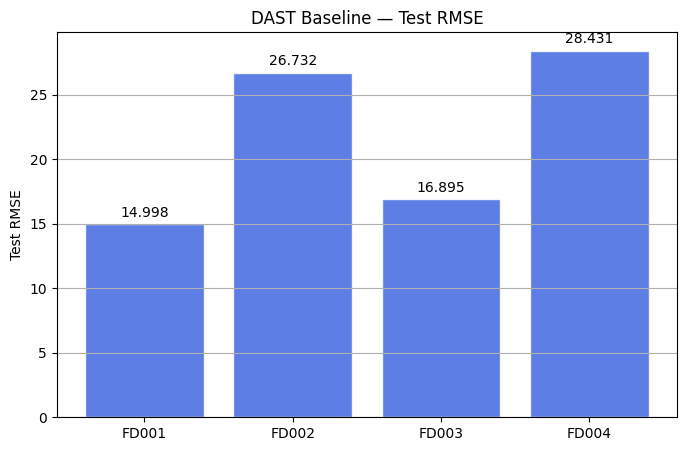


  Predictions saved in all_results[dataset]['test_preds']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# DAST — SNIPPET 2: TRAINING + EVALUATION + BASELINE (PHASE 0)
# NOTE: old in-process run_random_search / run_bayesian_opt / sample_hp_random /
# quick_val_rmse / DMODEL_HEADS_PAIRS / RANDOM_SPACE have been REMOVED — replaced
# by the subprocess-isolated, warm-started search in Snippets 3-5.
# ══════════════════════════════════════════════════════════════════════════════
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ══════════════════════════════════════════════════════════════════════════════
# CALLBACKS
# ══════════════════════════════════════════════════════════════════════════════
def get_callbacks(hp):
    return [
        EarlyStopping(
            monitor='val_loss', patience=hp['patience_es'],
            restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(
            monitor='val_loss', factor=hp['lr_factor'],
            patience=hp['patience_lr'],
            min_lr=hp['min_lr'], verbose=1)
    ]

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN AND EVALUATE
# ══════════════════════════════════════════════════════════════════════════════
def train_and_evaluate(dataset, hp, show_plots=True):
    """
    Full pipeline: load → preprocess → split → sequence → train → evaluate
    Returns dict with metrics and raw predictions for downstream ensemble use.
    """
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    train_raw, test_raw, y_test = load_data(dataset)
    train_df, test_df           = preprocess(train_raw.copy(), test_raw.copy(), dataset)
    if show_plots: plot_rul_dist(train_df, dataset)

    eids               = train_df['id'].unique()
    tr_e, val_e        = train_test_split(eids, test_size=0.2, random_state=SEED)
    X_train, y_train   = create_sequences(train_df[train_df['id'].isin(tr_e)], SEQ_LEN)
    X_val,   y_val     = create_sequences(train_df[train_df['id'].isin(val_e)], SEQ_LEN)
    X_test             = create_test_sequences(test_df, SEQ_LEN)

    print(f"  Train:{X_train.shape}  Val:{X_val.shape}  Test:{X_test.shape}")
    print(f"  HP: d={hp['d_model']} H={hp['n_heads']} "
          f"Ne={hp['n_enc_layers']} Nd={hp['n_dec_layers']} "
          f"ff={hp['ff_dim']} lr={hp['lr']:.0e} bs={hp['batch_size']}")

    model = build_dast(SEQ_LEN, N_FEATURES, hp)
    hist  = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=hp['epochs'],
        batch_size=hp['batch_size'],
        callbacks=get_callbacks(hp),
        verbose=0
    )

    vp = model.predict(X_val,  verbose=0).flatten()
    tp = model.predict(X_test, verbose=0).flatten()

    assert vp.shape == y_val.shape,  f"Val shape mismatch: {vp.shape}"
    assert tp.shape == y_test.shape, f"Test shape mismatch: {tp.shape}"

    print("\n  Val  ↓"); report_metrics('DAST', y_val, vp)
    print("  Test ↓"); r, m, ms, n = report_metrics('DAST', y_test, tp)

    if show_plots:
        plot_loss(hist, dataset)
        plot_predictions(y_test, tp, dataset)
        plot_residuals(y_test, tp, dataset)

    return {
        'rmse': r, 'mae': m, 'mse': ms, 'nasa': n,
        'test_preds': tp, 'val_preds': vp,
        'y_test': y_test, 'y_val': y_val
    }

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 0 — BASELINE: paper default HP, all 4 datasets
# ══════════════════════════════════════════════════════════════════════════════
DATASETS    = ['FD001','FD002','FD003','FD004']
all_results = {}

print(f"\n{'█'*60}")
print(f"  DAST BASELINE  —  Paper Default Hyperparameters")
print(f"  d_model={HP_DEFAULT['d_model']}  H={HP_DEFAULT['n_heads']}  "
      f"N_enc={HP_DEFAULT['n_enc_layers']}  N_dec={HP_DEFAULT['n_dec_layers']}")
print(f"  lr={HP_DEFAULT['lr']}  batch={HP_DEFAULT['batch_size']}  "
      f"dropout={HP_DEFAULT['dropout']}")
print(f"{'█'*60}")

for dataset in DATASETS:
    print(f"\n{'─'*55}\n  DATASET: {dataset}\n{'─'*55}")
    all_results[dataset] = train_and_evaluate(dataset, HP_DEFAULT)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  DAST BASELINE RESULTS")
print(f"{'═'*65}")
print(f"  {'Dataset':<10} {'RMSE':>8} {'MAE':>8} {'MSE':>10} {'NASA':>10}")
print(f"  {'':─<10} {'':─>8} {'':─>8} {'':─>10} {'':─>10}")
for ds in DATASETS:
    r = all_results[ds]
    print(f"  {ds:<10} {r['rmse']:>8.3f} {r['mae']:>8.3f} "
          f"{r['mse']:>10.3f} {r['nasa']:>10.1f}")
avg = np.mean([all_results[ds]['rmse'] for ds in DATASETS])
print(f"\n  Avg RMSE: {avg:.3f}")
plot_rmse_bar(all_results, 'DAST Baseline — Test RMSE')
print(f"\n  Predictions saved in all_results[dataset]['test_preds']")

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# DAST — SNIPPET 3 (NEW): SUBPROCESS WORKER + MEMORY-SAFE SEARCH HELPERS
#
# FIX FOR RAM CRASHES DURING BAYESIAN OPT:
#   - Every trial (Random AND Bayesian) trains inside a FRESH subprocess.
#   - OS reclaims 100% of TF/Keras memory when the subprocess exits.
#   - Parent process never holds a model, history, or prediction array —
#     only the scalar val_rmse returned by the worker.
#   - Train/val arrays are written to disk ONCE; each worker loads them from
#     disk, so the parent is freed of them during the whole search.
#
# NEW: smoke_test_worker() — runs ONE real subprocess trial before the search.
# On failure, prints the FULL worker stderr (not a truncated tail), so any
# build error is visible immediately instead of repeating 40x as `inf`.
# ══════════════════════════════════════════════════════════════════════════════
import gc, optuna, subprocess, json, sys, os, ctypes
optuna.logging.set_verbosity(optuna.logging.WARNING)

WORKER_PATH  = '/tmp/dast_worker.py'
ARRAY_PREFIX = '/tmp/dast_arrays'

def _trim_ram():
    try: ctypes.cdll.LoadLibrary("libc.so.6").malloc_trim(0)
    except Exception: pass

# ── Worker script — runs in its own process, dies after one trial ─────────────
WORKER_CODE = r"""
import os, sys, json, numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS']       = 'ignore'
import warnings; warnings.filterwarnings('ignore')

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    except: pass

from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Flatten, Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

class SinusoidalPE(Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(trainable=False, **kwargs)
        pos  = np.arange(seq_len)[:, None].astype(np.float32)
        dims = np.arange(d_model)[None, :].astype(np.float32)
        ang  = pos / np.power(10000.0, (2*(dims//2)) / float(d_model))
        pe   = np.zeros_like(ang, dtype=np.float32)
        pe[:, 0::2] = np.sin(ang[:, 0::2])
        pe[:, 1::2] = np.cos(ang[:, 1::2])
        self._pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        return x + self._pe

class EncoderBlock(Layer):
    def __init__(self, d_model, n_heads, ff_dim, dropout, **kwargs):
        super().__init__(**kwargs)
        self.mha   = MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.ff1   = Dense(ff_dim, activation='relu')
        self.ff2   = Dense(d_model)
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)

    def call(self, x, training=False):
        attn = self.mha(x, x, training=training)
        x    = self.norm1(x + self.drop1(attn, training=training))
        ffn  = self.ff2(self.ff1(x))
        x    = self.norm2(x + self.drop2(ffn, training=training))
        return x

class DecoderBlock(Layer):
    def __init__(self, d_model, n_heads, ff_dim, dropout, **kwargs):
        super().__init__(**kwargs)
        self.mha_self  = MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.mha_cross = MultiHeadAttention(
            num_heads=n_heads, key_dim=d_model//n_heads, dropout=dropout)
        self.ff1   = Dense(ff_dim, activation='relu')
        self.ff2   = Dense(d_model)
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.norm3 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)
        self.drop3 = Dropout(dropout)

    def call(self, x, enc_output, training=False):
        T = tf.shape(x)[1]
        causal = tf.linalg.band_part(
            tf.ones((T, T), dtype=tf.bool), -1, 0)
        a1 = self.mha_self(x, x, attention_mask=causal, training=training)
        x  = self.norm1(x + self.drop1(a1, training=training))
        a2 = self.mha_cross(x, enc_output, training=training)
        x  = self.norm2(x + self.drop2(a2, training=training))
        ffn = self.ff2(self.ff1(x))
        x   = self.norm3(x + self.drop3(ffn, training=training))
        return x

class DASTModel(tf.keras.Model):
    def __init__(self, seq_len, n_features, hp):
        super().__init__()
        D  = hp['d_model']; nh = hp['n_heads']
        ne = hp['n_enc_layers']; nd = hp['n_dec_layers']
        ff = hp['ff_dim']; dr = hp['dropout']; fc = hp['fc_units']

        self.s_embed = Dense(D, name='s_embed')
        self.s_pe    = SinusoidalPE(n_features, D, name='s_pe')
        self.s_drop  = Dropout(dr)
        self.s_enc   = [EncoderBlock(D, nh, ff, dr, name=f's_enc_{i}') for i in range(ne)]

        self.ts_embed = Dense(D, name='ts_embed')
        self.ts_pe    = SinusoidalPE(seq_len, D, name='ts_pe')
        self.ts_drop  = Dropout(dr)
        self.ts_enc   = [EncoderBlock(D, nh, ff, dr, name=f'ts_enc_{i}') for i in range(ne)]

        self.fusion = Dense(D, name='fusion')

        self.dec_embed = Dense(D, name='dec_embed')
        self.dec_pe    = SinusoidalPE(seq_len, D, name='dec_pe')
        self.dec_drop  = Dropout(dr)
        self.dec_layers = [DecoderBlock(D, nh, ff, dr, name=f'dec_{i}') for i in range(nd)]

        self.flat    = Flatten()
        self.fc      = Dense(fc, activation='relu', name='fc')
        self.fc_drop = Dropout(dr)
        self.out     = Dense(1, name='rul_output')

    def call(self, inputs, training=False):
        s = tf.transpose(inputs, perm=[0, 2, 1])
        s = self.s_embed(s); s = self.s_pe(s); s = self.s_drop(s, training=training)
        for enc in self.s_enc: s = enc(s, training=training)
        Fs = s

        t = self.ts_embed(inputs); t = self.ts_pe(t); t = self.ts_drop(t, training=training)
        for enc in self.ts_enc: t = enc(t, training=training)
        Ft = t

        Fr = tf.concat([Fs, Ft], axis=1)
        Fr = self.fusion(Fr)

        dec = self.dec_embed(inputs); dec = self.dec_pe(dec); dec = self.dec_drop(dec, training=training)
        for layer in self.dec_layers:
            dec = layer(dec, Fr, training=training)

        x   = self.flat(dec)
        x   = self.fc(x)
        x   = self.fc_drop(x, training=training)
        return self.out(x)

def build_dast(seq_len, n_features, hp):
    model = DASTModel(seq_len, n_features, hp)
    _ = model(tf.zeros((2, seq_len, n_features)), training=False)
    model.compile(optimizer=Adam(learning_rate=hp['lr'], clipnorm=1.0),
                   loss='mse', metrics=['mae'])
    return model

hp     = json.loads(sys.argv[1])
prefix = sys.argv[2]
SEQ    = int(sys.argv[3])

Xtr  = np.load(f'{prefix}_Xtr.npy')
ytr  = np.load(f'{prefix}_ytr.npy')
Xval = np.load(f'{prefix}_Xval.npy')
yval = np.load(f'{prefix}_yval.npy')
N_FEATURES = Xtr.shape[2]

cbs = [EarlyStopping(monitor='val_loss', patience=hp['patience_es'],
                     restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=hp.get('patience_lr', 5), min_lr=1e-7)]
try:
    m = build_dast(SEQ, N_FEATURES, hp)
    m.fit(Xtr, ytr, validation_data=(Xval, yval),
          epochs=hp['epochs'], batch_size=hp['batch_size'],
          callbacks=cbs, verbose=0)
    for cb in cbs:
        if hasattr(cb, 'best_weights'): cb.best_weights = None
    vp = m.predict(Xval, verbose=0).flatten()
    print(float(np.sqrt(mean_squared_error(yval, vp))))
    sys.exit(0)
except Exception:
    import traceback; traceback.print_exc(file=sys.stderr)
    sys.exit(1)
"""

# ── Write worker to disk ───────────────────────────────────────────────────────
def write_worker():
    with open(WORKER_PATH, 'w') as f:
        f.write(WORKER_CODE)
    print(f"  Worker written → {WORKER_PATH}")

# ── Run one trial in a fresh subprocess ────────────────────────────────────────
def run_isolated(hp, timeout=420):
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH, json.dumps(hp), ARRAY_PREFIX, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0 and r.stdout.strip():
            return float(r.stdout.strip())
        if r.stderr:
            print(f"    [err] {r.stderr.strip()[-200:]}")
        return float('inf')
    except subprocess.TimeoutExpired:
        print(f"    [timeout {timeout}s]")
        return float('inf')
    except Exception as e:
        print(f"    [exc] {e}")
        return float('inf')

# ── NEW: fail-fast smoke test — ONE real subprocess trial, full stderr on fail ─
def smoke_test_worker(epochs_search=2, timeout=180):
    test_hp = {
        'd_model': 32, 'n_heads': 4, 'n_enc_layers': 1, 'n_dec_layers': 1,
        'ff_dim': 64, 'fc_units': 32, 'dropout': 0.1, 'lr': 1e-3,
        'batch_size': 64, 'epochs': epochs_search,
        'patience_es': 5, 'patience_lr': 3,
    }
    print(f"\n  ── Smoke test: 1 subprocess trial ({epochs_search} epochs) ──")
    try:
        r = subprocess.run(
            [sys.executable, WORKER_PATH, json.dumps(test_hp), ARRAY_PREFIX, str(SEQ_LEN)],
            capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print(f"  Smoke test TIMED OUT after {timeout}s")
        return False

    if r.returncode == 0 and r.stdout.strip():
        print(f"  Smoke test OK — val RMSE: {float(r.stdout.strip()):.3f}")
        return True

    print(f"  Smoke test FAILED — full worker stderr:\n{r.stderr}")
    return False

# ── Save precomputed sequences to disk, free from parent RAM ──────────────────
def save_arrays(Xtr, ytr, Xval, yval):
    np.save(f'{ARRAY_PREFIX}_Xtr.npy',  Xtr)
    np.save(f'{ARRAY_PREFIX}_ytr.npy',  ytr)
    np.save(f'{ARRAY_PREFIX}_Xval.npy', Xval)
    np.save(f'{ARRAY_PREFIX}_yval.npy', yval)
    mb = (Xtr.nbytes + Xval.nbytes) / 1e6
    print(f"  Arrays saved to {ARRAY_PREFIX}_*.npy  ({mb:.0f} MB on disk)")

# ── Warm-start Bayesian Phase 2 from top-N Random Search trials ──────────────
def _run_phase2(rs, n_bayes, top_n, objective_fn):
    """
    Ranks Phase-1 (Random Search) trials by val RMSE, takes the top `top_n`
    (param, distribution, value) triples, and seeds a TPE-based Bayesian
    study with them via add_trial — ZERO re-evaluation, ZERO extra GPU cost.
    Bayesian search then explores around these promising regions.
    """
    sorted_t    = sorted(rs.trials, key=lambda t: t.value)
    seeds       = [(t.params, t.distributions, t.value) for t in sorted_t[:top_n]]
    p1_best     = sorted_t[0].value
    del sorted_t; gc.collect()

    bs = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=top_n))

    for p, d, v in seeds:
        bs.add_trial(optuna.trial.create_trial(params=p, distributions=d, value=v))
    del seeds; gc.collect()

    print(f"  {top_n} seeds transferred (0 GPU). Running {n_bayes} new Bayesian trials...")

    def _cb(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")
        gc.collect(); _trim_ram()

    bs.optimize(objective_fn, n_trials=n_bayes, callbacks=[_cb])

    best = bs.best_trial
    print(f"\n  Phase1 best={p1_best:.3f}  Phase2 best={best.value:.3f}  "
          f"Δ={p1_best-best.value:+.3f}")

    try:
        imp = optuna.importance.get_param_importances(bs)
        plt.figure(figsize=(10, 4))
        plt.barh(list(imp.keys()), list(imp.values()), color='royalblue')
        plt.title('HP Importance — DAST (Subprocess Bayesian)')
        plt.tight_layout(); plt.grid(axis='x'); plt.show()
    except Exception:
        pass
    return bs

print("DAST subprocess worker + search helpers loaded.")

DAST subprocess worker + search helpers loaded.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# DAST — SNIPPET 4 (NEW): COMBINED RANDOM + WARM-STARTED BAYESIAN SEARCH
#
# - (d_model, n_heads) sampled jointly via pair_idx → DMODEL_HEADS_PAIRS to
#   enforce d_model % n_heads == 0 (same pattern as TCN's dil_idx)
# - Phase 1: RandomSampler explores the full search space (subprocess per trial)
# - Phase 2: top-5 Phase-1 trials seed a TPESampler study (via _run_phase2),
#            which then runs n_bayes additional trials around those regions
# - smoke_test_worker() gates Phase 1 — aborts with full traceback on failure
#   instead of repeating the failure for all 40 trials
# ══════════════════════════════════════════════════════════════════════════════
DMODEL_HEADS_PAIRS = [(32, 4), (64, 4), (64, 8), (128, 4), (128, 8)]

def dast_combined_search(n_random=20, n_bayes=20, top_n=5,
                          dataset='FD001', epochs_search=40):
    print(f"\n{'═'*65}")
    print(f"  DAST COMBINED SEARCH  |  {dataset}")
    print(f"  Phase1: Random {n_random}  |  Phase2: Bayesian {n_bayes} new trials "
          f"(seeded with top {top_n})")
    print(f"  Each trial = fresh subprocess → TF RAM fully reclaimed after exit")
    print(f"  Total subprocess evaluations: {n_random + n_bayes}")
    print(f"{'═'*65}")

    write_worker()

    # ── Precompute sequences, save to disk, FREE from parent RAM ──────────────
    tr, _, _    = load_data(dataset)
    train_df, _ = preprocess(tr.copy(), tr.copy(), dataset)
    del tr
    eids        = train_df['id'].unique()
    tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
    Xtr,  ytr   = create_sequences(train_df[train_df['id'].isin(tr_e)],  SEQ_LEN)
    Xval, yval  = create_sequences(train_df[train_df['id'].isin(val_e)], SEQ_LEN)
    del train_df
    save_arrays(Xtr, ytr, Xval, yval)
    del Xtr, ytr, Xval, yval
    gc.collect(); _trim_ram()

    # ── Fail-fast gate before launching the full search ────────────────────────
    if not smoke_test_worker(epochs_search=2):
        print("\n  ABORTING — fix DASTModel / WORKER_CODE using the traceback above.")
        print("  Re-run Snippet 1 (confirm the forward+backward smoke test passes),")
        print("  then re-run Snippet 3, then retry Snippet 5.")
        return None, None, None

    # ── Objective: one subprocess per trial ─────────────────────────────────────
    def objective(trial):
        pair_idx = trial.suggest_categorical(
            'pair_idx', list(range(len(DMODEL_HEADS_PAIRS))))
        d_model, n_heads = DMODEL_HEADS_PAIRS[pair_idx]
        hp = {
            'd_model'     : d_model,
            'n_heads'     : n_heads,
            'n_enc_layers': trial.suggest_int('n_enc_layers', 1, 4),
            'n_dec_layers': trial.suggest_int('n_dec_layers', 1, 2),
            'ff_dim'      : trial.suggest_categorical('ff_dim', [64, 128, 256]),
            'fc_units'    : trial.suggest_categorical('fc_units', [32, 64, 128]),
            'dropout'     : trial.suggest_float('dropout', 0.10, 0.40),
            'lr'          : trial.suggest_float('lr', 1e-4, 5e-3, log=True),
            'batch_size'  : trial.suggest_categorical('batch_size', [32, 64, 128]),
            'epochs'      : epochs_search,
            'patience_es' : 10,
            'patience_lr' : 4,
        }
        return run_isolated(hp)

    # ── Phase 1: Random Search ──────────────────────────────────────────────────
    print(f"\n  ── Phase 1: Random Search ({n_random} trials) ──")
    rs = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.RandomSampler(seed=SEED))

    def _cb1(study, trial):
        v   = trial.value
        tag = '← BEST' if v == study.best_value else ''
        print(f"    Trial {trial.number+1:3d}: "
              f"{'inf' if v==float('inf') else f'{v:.3f}'} {tag}")
        gc.collect(); _trim_ram()

    rs.optimize(objective, n_trials=n_random, callbacks=[_cb1])

    print(f"\n  Top {top_n} from Phase 1:")
    sorted_show = sorted(rs.trials, key=lambda t: t.value)
    for i, t in enumerate(sorted_show[:top_n]):
        p = t.params
        d_model, n_heads = DMODEL_HEADS_PAIRS[p['pair_idx']]
        print(f"    #{i+1}  RMSE={t.value:.3f}  d={d_model}  H={n_heads}  "
              f"Ne={p['n_enc_layers']}  lr={p['lr']:.1e}")
    del sorted_show

    # ── Phase 2: Bayesian, warm-started with top-N seeds ────────────────────────
    print(f"\n  ── Phase 2: Bayesian ({n_bayes} new trials, seeded from Phase 1) ──")
    bs = _run_phase2(rs, n_bayes, top_n, objective)

    # ── Build best HP for full retraining ───────────────────────────────────────
    p = bs.best_trial.params
    d_model, n_heads = DMODEL_HEADS_PAIRS[p['pair_idx']]
    best_hp = {
        'd_model'     : d_model,
        'n_heads'     : n_heads,
        'n_enc_layers': p['n_enc_layers'],
        'n_dec_layers': p['n_dec_layers'],
        'ff_dim'      : p['ff_dim'],
        'fc_units'    : p['fc_units'],
        'dropout'     : p['dropout'],
        'lr'          : p['lr'],
        'batch_size'  : p['batch_size'],
        'epochs'      : 100,
        'patience_es' : 20,
        'patience_lr' : 7,
        'lr_factor'   : 0.5,
        'min_lr'      : 1e-7,
        'weight_decay': 0.0,
    }
    print(f"\n  Best HP: {best_hp}")
    return best_hp, rs, bs

print("DAST combined search function loaded. Run Snippet 5 to start search.")

DAST combined search function loaded. Run Snippet 5 to start search.



═════════════════════════════════════════════════════════════════
  DAST COMBINED SEARCH  |  FD001
  Phase1: Random 20  |  Phase2: Bayesian 20 new trials (seeded with top 5)
  Each trial = fresh subprocess → TF RAM fully reclaimed after exit
  Total subprocess evaluations: 40
═════════════════════════════════════════════════════════════════
  Worker written → /tmp/dast_worker.py
  Arrays saved to /tmp/dast_arrays_*.npy  (48 MB on disk)

  ── Smoke test: 1 subprocess trial (2 epochs) ──
  Smoke test OK — val RMSE: 14.876

  ── Phase 1: Random Search (20 trials) ──
    Trial   1: 11.316 ← BEST
    Trial   2: 18.221 
    Trial   3: 11.225 ← BEST
    Trial   4: 13.315 
    Trial   5: 11.281 
    Trial   6: 15.542 
    Trial   7: 13.198 
    Trial   8: 16.714 
    Trial   9: 12.524 
    Trial  10: 11.312 
    Trial  11: 12.270 
    Trial  12: 13.311 
    Trial  13: 10.844 ← BEST
    Trial  14: 20.894 
    Trial  15: 13.338 
    Trial  16: 11.196 
    Trial  17: 13.093 
    Trial  18: 10.91

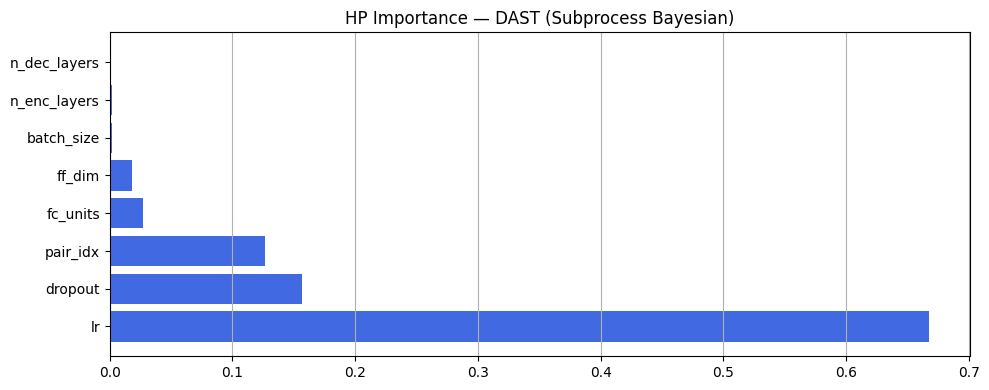


  Best HP: {'d_model': 64, 'n_heads': 4, 'n_enc_layers': 4, 'n_dec_layers': 2, 'ff_dim': 256, 'fc_units': 64, 'dropout': 0.11548396894805191, 'lr': 0.0012416662791977075, 'batch_size': 128, 'epochs': 100, 'patience_es': 20, 'patience_lr': 7, 'lr_factor': 0.5, 'min_lr': 1e-07, 'weight_decay': 0.0}


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# DAST — SNIPPET 5: RUN SEARCH
# ══════════════════════════════════════════════════════════════════════════════
best_hp_dast, rs_dast, bo_dast = dast_combined_search(
    n_random=20, n_bayes=20, top_n=5,
    dataset='FD001', epochs_search=40)


██████████████████████████████████████████████████
  DAST | FD001
██████████████████████████████████████████████████

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0006208331324160099.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.00031041656620800495.

  Val:
  DAST                                     RMSE=10.659  MAE=7.656  NASA=6128.8
  Test:
  DAST                                     RMSE=14.206  MAE=10.113  NASA=358.6


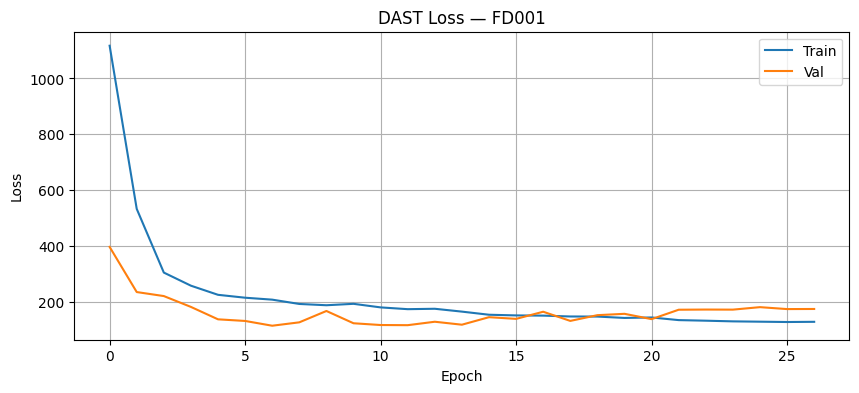

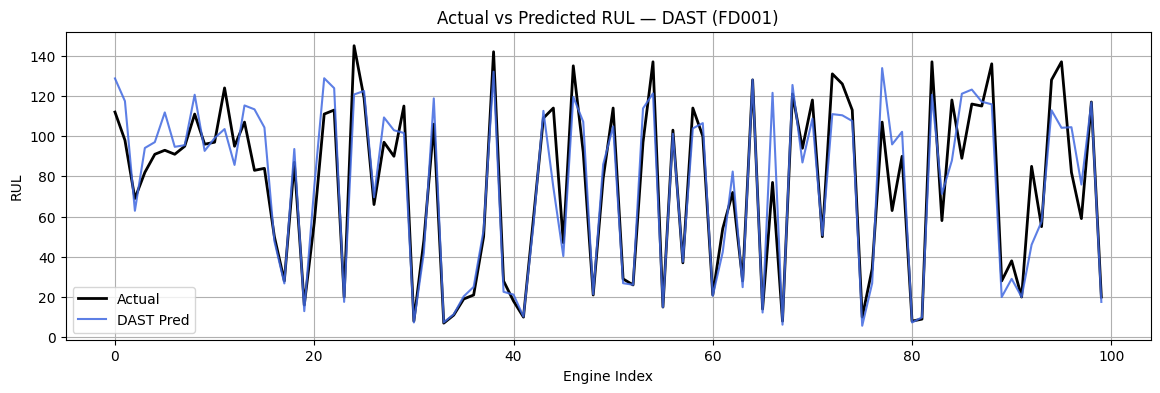


██████████████████████████████████████████████████
  DAST | FD002
██████████████████████████████████████████████████

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0006208331324160099.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.00031041656620800495.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.00015520828310400248.

  Val:
  DAST                                     RMSE=17.996  MAE=13.471  NASA=78497.8
  Test:
  DAST                                     RMSE=28.356  MAE=19.690  NASA=10455.6


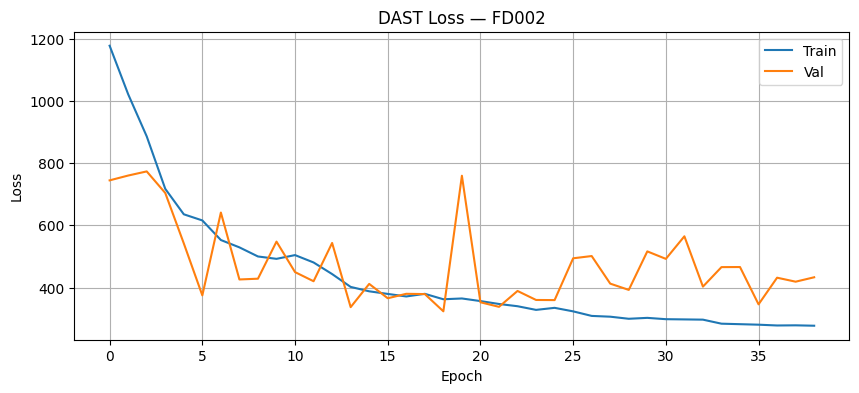

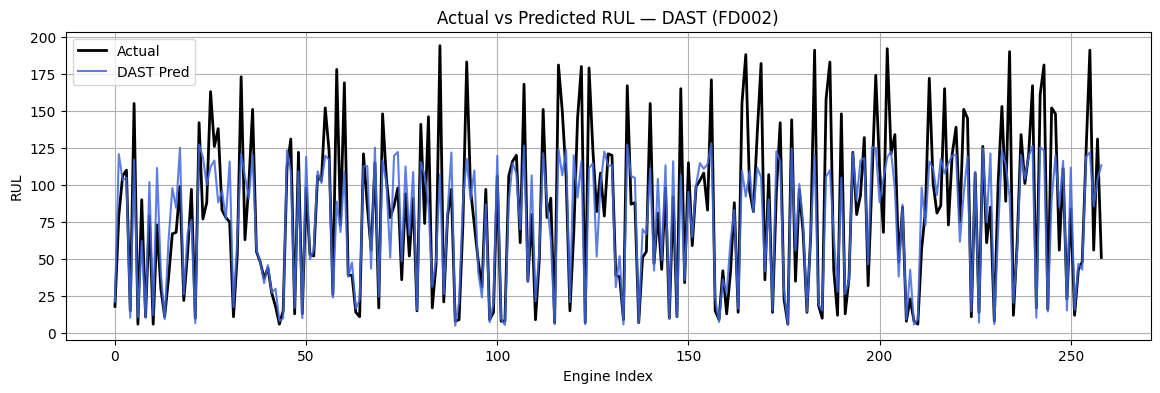


██████████████████████████████████████████████████
  DAST | FD003
██████████████████████████████████████████████████

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0006208331324160099.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.00031041656620800495.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.00015520828310400248.

Epoch 52: ReduceLROnPlateau reducing learning rate to 7.760414155200124e-05.

  Val:
  DAST                                     RMSE=10.745  MAE=7.797  NASA=8477.0
  Test:
  DAST                                     RMSE=16.261  MAE=11.660  NASA=591.6


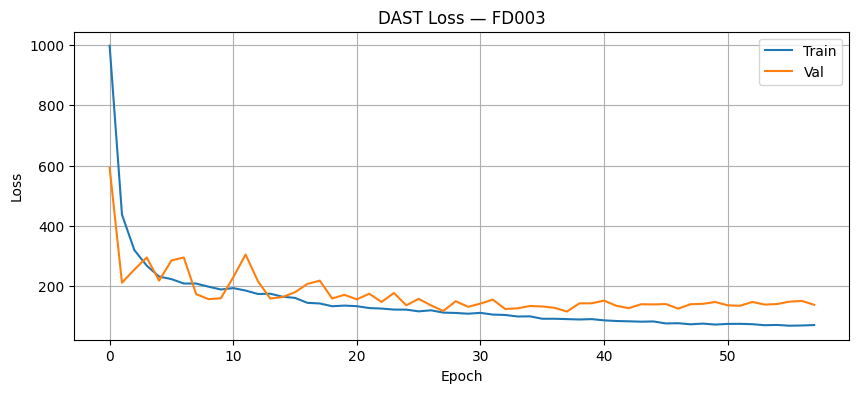

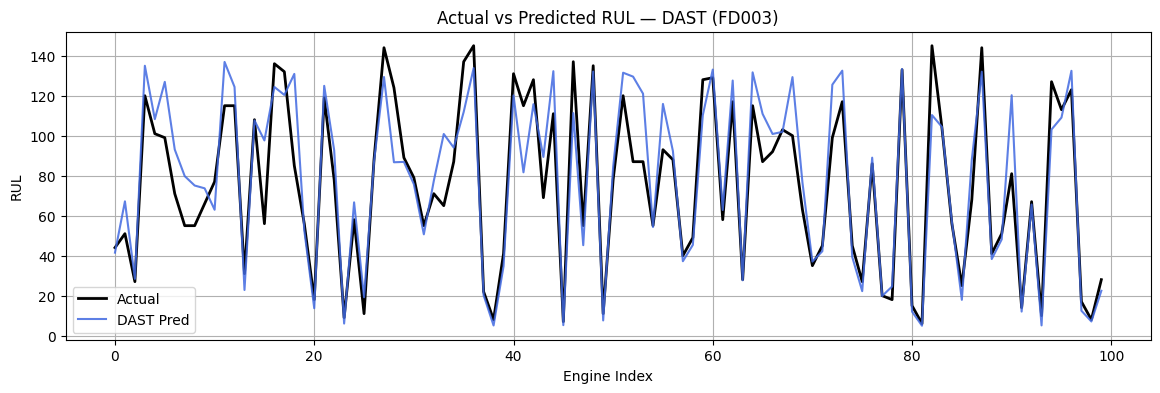


██████████████████████████████████████████████████
  DAST | FD004
██████████████████████████████████████████████████

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0006208331324160099.

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.00031041656620800495.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.00015520828310400248.

Epoch 49: ReduceLROnPlateau reducing learning rate to 7.760414155200124e-05.

  Val:
  DAST                                     RMSE=20.411  MAE=13.450  NASA=905549.2
  Test:
  DAST                                     RMSE=27.693  MAE=20.194  NASA=5307.8


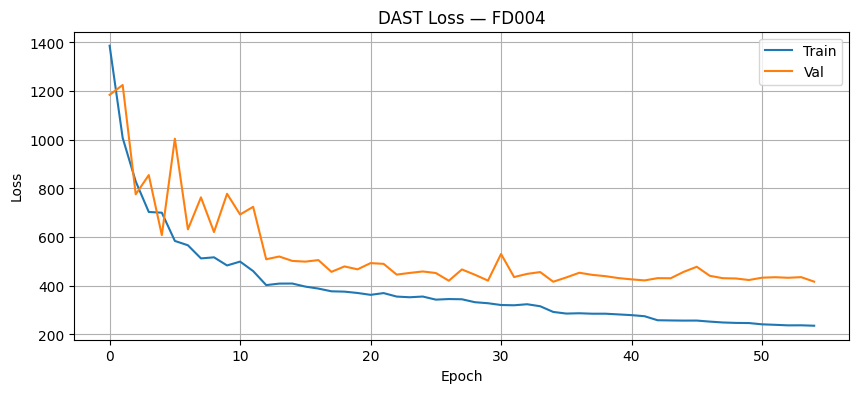

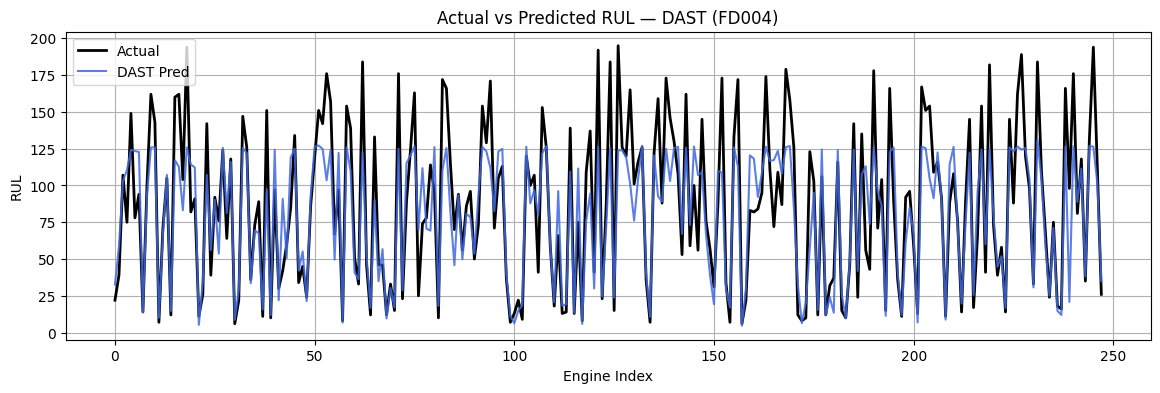


════════════════════════════════════════════════════════════
  DS             RMSE    vs Baseline
  ──────── ────────── ──────────────
  FD001        14.206          -0.792
  FD002        28.356          +1.624
  FD003        16.261          -0.634
  FD004        27.693          -0.737


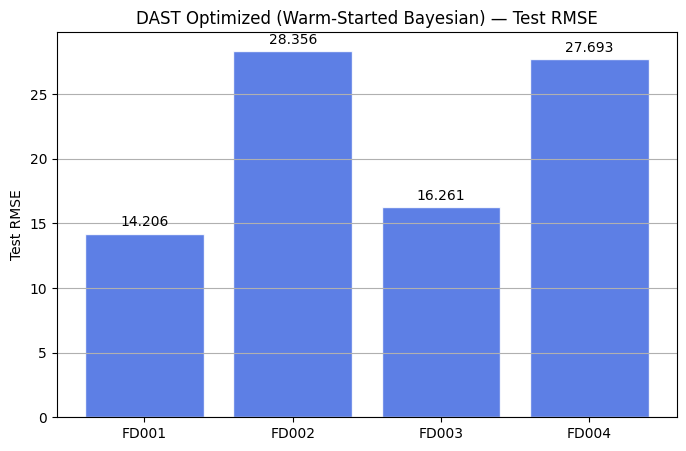

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# DAST — SNIPPET 6: RETRAIN BEST HP ON ALL 4 DATASETS
# Runs in-process (only 4 training runs — subprocess isolation not needed here).
# Explicit per-dataset memory cleanup (gc + clear_session + _trim_ram) keeps RAM
# flat across the 4 retrains, mirroring the safety added to the search phases.
# ══════════════════════════════════════════════════════════════════════════════
optimized_dast = {}

for dataset in DATASETS:
    print(f"\n{'█'*50}\n  DAST | {dataset}\n{'█'*50}")
    np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

    X_train = y_train = X_val = y_val = X_test = model = cbs = None
    try:
        tr, te, y_test = load_data(dataset)
        train_df, test_df = preprocess(tr.copy(), te.copy(), dataset)
        del tr, te

        eids        = train_df['id'].unique()
        tr_e, val_e = train_test_split(eids, test_size=0.2, random_state=SEED)
        X_train, y_train = create_sequences(train_df[train_df['id'].isin(tr_e)],  SEQ_LEN)
        X_val,   y_val   = create_sequences(train_df[train_df['id'].isin(val_e)], SEQ_LEN)
        X_test           = create_test_sequences(test_df, SEQ_LEN)
        del train_df, test_df

        model = build_dast(SEQ_LEN, N_FEATURES, best_hp_dast)
        cbs   = get_callbacks(best_hp_dast)
        hist  = model.fit(X_train, y_train,
                           validation_data=(X_val, y_val),
                           epochs=best_hp_dast['epochs'],
                           batch_size=best_hp_dast['batch_size'],
                           callbacks=cbs, verbose=0)

        vp = model.predict(X_val,  verbose=0).flatten()
        tp = model.predict(X_test, verbose=0).flatten()

        print("\n  Val:")
        report_metrics("DAST", y_val, vp)
        print("  Test:")
        r, m, ms, n = report_metrics("DAST", y_test, tp)
        optimized_dast[dataset] = {'rmse': r, 'mae': m, 'mse': ms, 'nasa': n, 'test_preds': tp}

        plot_loss(hist, dataset)
        plot_predictions(y_test, tp, dataset)
        del vp, hist

    finally:
        if cbs is not None:
            for cb in cbs:
                if hasattr(cb, 'best_weights'): cb.best_weights = None
        model = cbs = X_train = y_train = X_val = y_val = X_test = None
        tf.keras.backend.clear_session()
        gc.collect(); gc.collect()
        _trim_ram()

print(f"\n{'═'*60}")
print(f"  {'DS':<8} {'RMSE':>10} {'vs Baseline':>14}")
print(f"  {'':─<8} {'':─>10} {'':─>14}")
for ds in DATASETS:
    o = optimized_dast[ds]['rmse']
    b = all_results[ds]['rmse']
    print(f"  {ds:<8} {o:>10.3f}  {o-b:>+14.3f}")

plot_rmse_bar(optimized_dast, 'DAST Optimized (Warm-Started Bayesian) — Test RMSE')